# stratosampler — Examples

Covers the full workflow: loading molecules, stratified splitting, quality metrics, and visualisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from stratosampler import (
    PropertyStratifiedSplitter,
    compute_properties,
    BUILTIN_PROPERTIES,
    load_smiles,
    distribution_report,
    split_summary,
    coverage_score,
    plot_property_distributions,
    plot_split_comparison,
    plot_chemical_space,
)

## 1. Sample dataset

We build a small in-memory DataFrame of SMILES strings to keep this notebook self-contained. Swap in your own data at any point.

In [2]:
SMILES = [
    # lipophilic / large
    "Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1",  # imatinib
    "COc1ccc2nccc(OC)c2c1",
    "CC(C)(C)c1ccc(NC(=O)Nc2ccc(Cl)c(Cl)c2)cc1",
    "O=C(Nc1ccc(F)cc1)c1cnc2ccccc2c1",
    "Cc1cc(NC2=NC(=O)c3ccccc32)ccc1Cl",
    # polar / small
    "CC(=O)Nc1ccc(O)cc1",   # paracetamol
    "OC(=O)c1ccccc1O",      # salicylic acid
    "Nc1ccc(S(=O)(=O)N)cc1",
    "CC(O)=O",              # acetic acid
    "NCC(=O)O",             # glycine
    "OC[C@H](O)[C@@H](O)[C@H](O)CO",  # sorbitol
    "c1ccc(N)cc1",          # aniline
    "OC(=O)CCC(=O)O",
    # medium range
    "CCc1ccc(S(=O)(=O)N)cc1",
    "Cc1ccc(C(=O)O)cc1",
    "FC(F)(F)c1ccc(NC(=O)c2ccco2)cc1",
    "O=C(O)c1ccc(F)cc1",
    "Clc1ccccc1NC(=O)c1cccs1",
    "COc1ccc(C(=O)O)cc1",
    "c1ccc2[nH]ccc2c1",     # indole
    "O=c1[nH]cc[nH]1",
    "CCc1ccc(O)cc1",
    "CC(C)Cc1ccc(C(C)C(=O)O)cc1",   # ibuprofen
    "CC1(C)CC(=O)c2ccccc21",
    "O=C(O)CC(=O)O",        # malonic acid
    "OC(=O)c1ccc(O)cc1",
    "Cc1ccc(Cl)cc1",
    "CC(C)c1ccc(O)cc1",
    "CCCCC(=O)O",
    "CCc1ccc(Cl)cc1",
]

df = pd.DataFrame({"smiles": SMILES})
print(f"{len(df)} compounds")

30 compounds


## 2. Compute physicochemical properties

In [3]:
print("Available built-in properties:", list(BUILTIN_PROPERTIES.keys()))

Available built-in properties: ['MolLogP', 'MolWt', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotBonds', 'NumRings', 'NumAromaticRings', 'FractionCSP3', 'NumHeavyAtoms']


In [4]:
PROPS = ["MolLogP", "MolWt", "TPSA", "NumHDonors", "NumHAcceptors"]

prop_df = compute_properties(df["smiles"], PROPS)
df = pd.concat([df, prop_df], axis=1)
df.head()

,smiles,MolLogP,MolWt,TPSA,NumHDonors,NumHAcceptors
0,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...,4.59032,493.615,86.28,2,7
1,COc1ccc2nccc(OC)c2c1,2.25200,189.214,31.35,0,3
2,CC(C)(C)c1ccc(NC(=O)Nc2ccc(Cl)c(Cl)c2)cc1,5.93490,337.250,41.13,2,1
3,O=C(Nc1ccc(F)cc1)c1cnc2ccccc2c1,3.62620,266.275,41.99,1,2
4,Cc1cc(NC2=NC(=O)c3ccccc32)ccc1Cl,3.66092,270.719,41.46,1,2


In [5]:
df[PROPS].describe().round(2)

,MolLogP,MolWt,TPSA,NumHDonors,NumHAcceptors
count,30.00,30.00,30.00,30.00,30.00
mean,1.73,168.71,43.97,1.33,1.77
std,1.81,88.28,24.38,0.96,1.41
min,-2.95,60.05,0.00,0.00,0.00
25%,0.94,119.11,29.66,1.00,1.00
50%,1.61,140.36,41.30,1.00,2.00
75%,2.84,188.22,57.53,2.00,2.00
max,5.93,493.62,101.15,5.00,7.00


## 3. Basic train / test split

In [6]:
splitter = PropertyStratifiedSplitter(
    properties=PROPS,
    n_bins=4,
    test_size=0.2,
    random_state=42,
)

train_idx, test_idx = splitter.split(df, smiles_col="smiles")
print(f"Train: {len(train_idx)}  Test: {len(test_idx)}")

Train: 7  Test: 23


### Distribution quality report

In [7]:
report = distribution_report(df, train_idx, test_idx, PROPS)
report.round(3)

,property,train_mean,test_mean,ks_stat,ks_pval,js_divergence
0,MolLogP,1.746,1.726,0.174,0.982,0.438
1,MolWt,162.872,170.484,0.323,0.521,0.620
2,TPSA,47.346,42.937,0.323,0.521,0.718
3,NumHDonors,1.429,1.304,0.174,0.982,0.288
4,NumHAcceptors,1.714,1.783,0.236,0.862,0.390


`ks_stat` close to 0 and `js_divergence` close to 0 mean train and test follow similar distributions.

### Property distribution plots

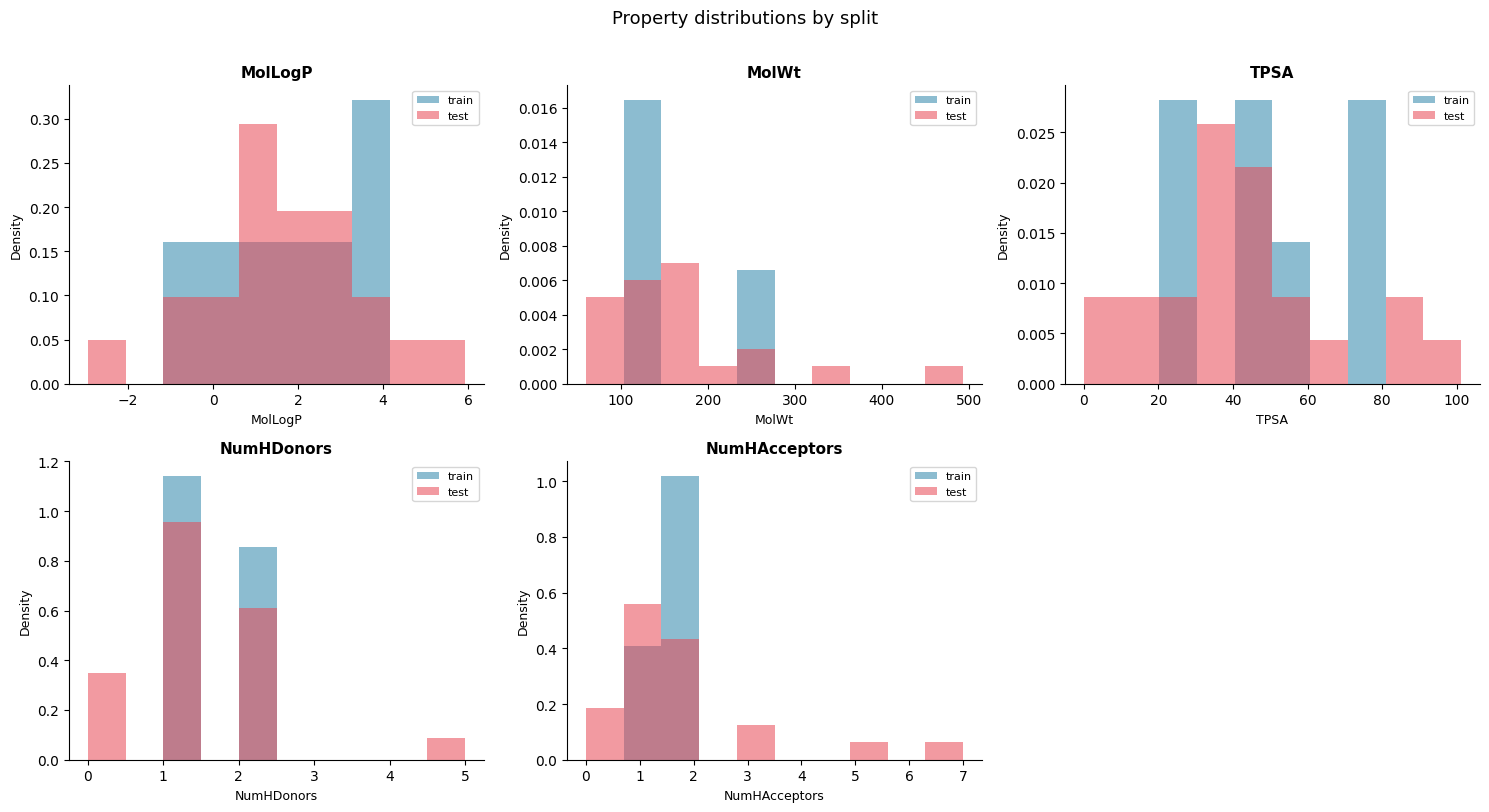

In [8]:
fig = plot_property_distributions(df, train_idx, test_idx, PROPS, n_bins=10)
plt.tight_layout()
plt.show()

## 4. Train / validation / test split

In [9]:
splitter3 = PropertyStratifiedSplitter(
    properties=["MolLogP", "MolWt", "TPSA"],
    n_bins=4,
    test_size=0.15,
    val_size=0.15,
    random_state=42,
)

train_idx3, val_idx3, test_idx3 = splitter3.split(df, smiles_col="smiles")
print(f"Train: {len(train_idx3)}  Val: {len(val_idx3)}  Test: {len(test_idx3)}")

Train: 4  Val: 7  Test: 19


In [10]:
report3 = distribution_report(df, train_idx3, test_idx3, PROPS, val_idx=val_idx3)
report3.round(3)

,property,train_mean,test_mean,ks_stat,ks_pval,js_divergence,val_mean,val_ks_stat,val_js_divergence
0,MolLogP,1.269,1.656,0.342,0.716,0.638,2.199,0.500,0.660
1,MolWt,167.289,160.986,0.263,0.929,0.683,190.475,0.357,0.751
2,TPSA,55.618,39.702,0.395,0.555,0.744,48.881,0.357,0.501
3,NumHDonors,1.500,1.263,0.211,0.991,0.332,1.429,0.071,0.051
4,NumHAcceptors,2.000,1.737,0.329,0.767,0.395,1.714,0.250,0.311


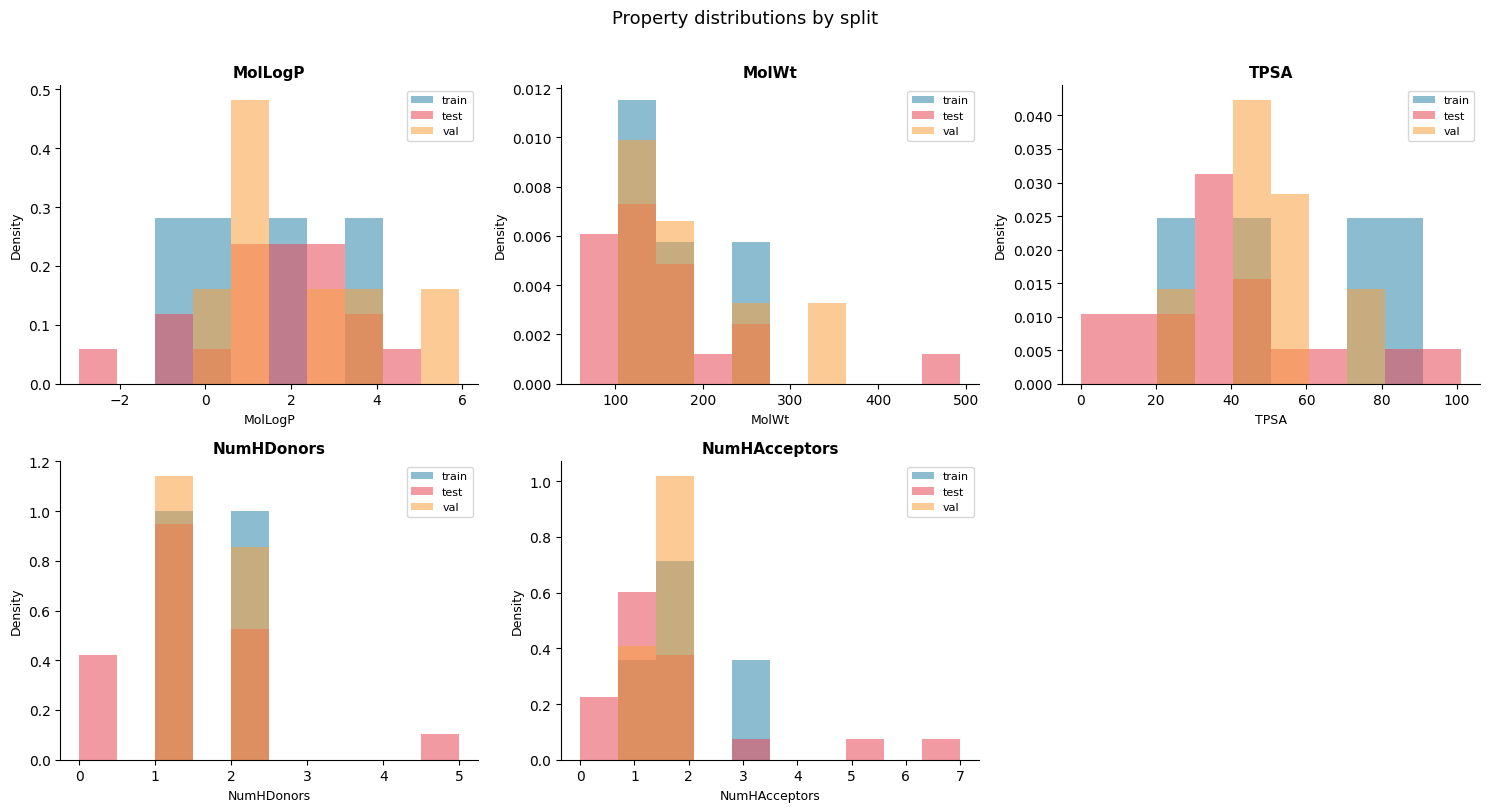

In [11]:
fig3 = plot_property_distributions(
    df, train_idx3, test_idx3, PROPS, val_idx=val_idx3, n_bins=10
)
plt.tight_layout()
plt.show()

## 5. get_split_dataframes — work directly with DataFrames

In [12]:
train_df, test_df = splitter.get_split_dataframes(df, smiles_col="smiles")
print(f"train_df: {train_df.shape}  test_df: {test_df.shape}")
train_df.head()

train_df: (7, 6)  test_df: (23, 6)


,smiles,MolLogP,MolWt,TPSA,NumHDonors,NumHAcceptors
0,OC(=O)CCC(=O)O,-0.0642,118.088,74.60,2,2
1,O=C(O)CC(=O)O,-0.4543,104.061,74.60,2,2
2,OC(=O)c1ccccc1O,1.0904,138.122,57.53,2,2
3,CCc1ccc(O)cc1,1.9546,122.167,20.23,1,1
4,CC(C)c1ccc(O)cc1,2.5156,136.194,20.23,1,1


## 6. Scaffold-aware splitting

With `scaffold_aware=True`, molecules sharing the same Murcko scaffold are kept together in the same split, preventing data leakage between structurally similar compounds.

In [13]:
splitter_scaffold = PropertyStratifiedSplitter(
    properties=["MolLogP", "MolWt"],
    n_bins=4,
    test_size=0.2,
    scaffold_aware=True,
    random_state=42,
)

train_sc, test_sc = splitter_scaffold.split(df, smiles_col="smiles")
print(f"Train: {len(train_sc)}  Test: {len(test_sc)}")

Train: 11  Test: 19


## 7. Using pre-computed property columns

If properties are already in the DataFrame, pass them via `property_cols` to skip RDKit computation.

In [14]:
splitter_cols = PropertyStratifiedSplitter(
    properties=["MolLogP", "MolWt", "TPSA"],
    n_bins=4,
    test_size=0.2,
    random_state=0,
)

train_c, test_c = splitter_cols.split(df, property_cols=["MolLogP", "MolWt", "TPSA"])
print(f"Train: {len(train_c)}  Test: {len(test_c)}")

Train: 11  Test: 19


## 8. Stratified vs random split — quality comparison

In [15]:
rng = np.random.default_rng(42)
n = len(df)
perm = rng.permutation(n)
cut = int(n * 0.8)
rand_train = perm[:cut]
rand_test = perm[cut:]

summary_random = split_summary(df, rand_train, rand_test, PROPS)
summary_strat = split_summary(df, train_idx, test_idx, PROPS)

print(f"Random   — mean KS: {summary_random['mean_ks_stat']:.3f}  mean JS: {summary_random['mean_js_div']:.3f}")
print(f"Stratified— mean KS: {summary_strat['mean_ks_stat']:.3f}  mean JS: {summary_strat['mean_js_div']:.3f}")

Random   — mean KS: 0.308  mean JS: 0.463
Stratified— mean KS: 0.246  mean JS: 0.491


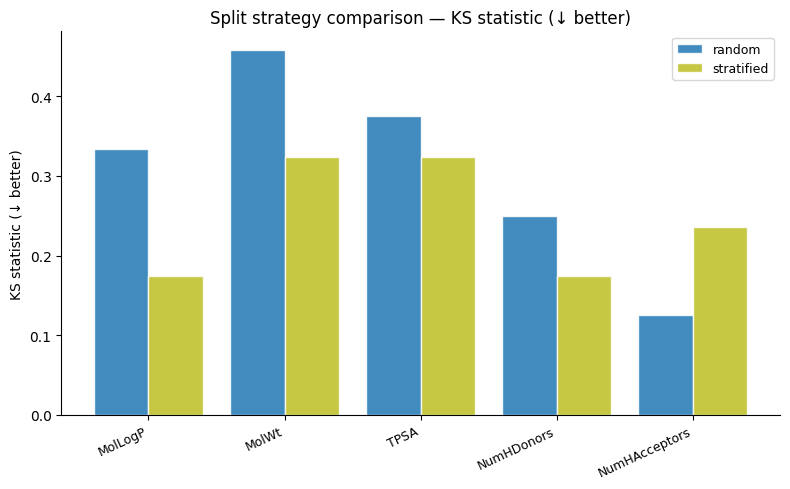

In [16]:
fig_cmp = plot_split_comparison(
    {"random": summary_random, "stratified": summary_strat},
    PROPS,
    metric="ks_stat",
)
plt.tight_layout()
plt.show()

## 9. Chemical space visualisation

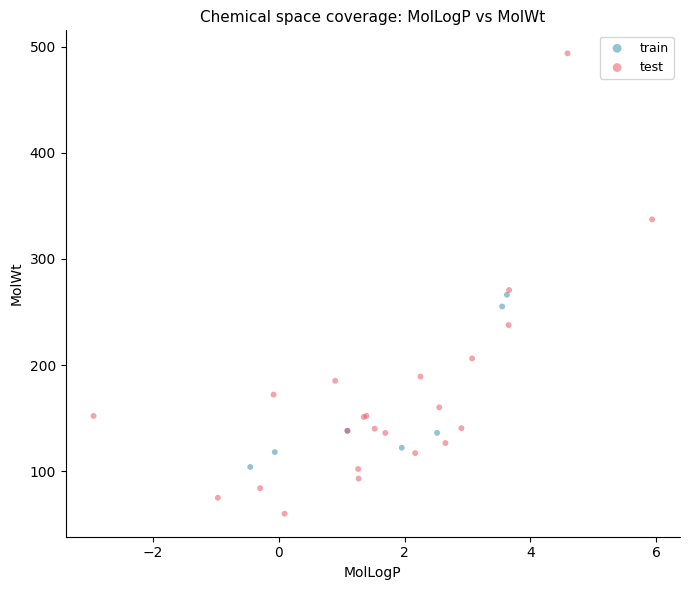

In [17]:
fig_cs = plot_chemical_space(df, train_idx, test_idx, x_col="MolLogP", y_col="MolWt")
plt.tight_layout()
plt.show()

## 10. Coverage score

Fraction of strata that appear in both train and test — 1.0 is ideal.

In [18]:
from stratosampler import coverage_score
from stratosampler.splitters.property_stratified import compute_properties
from sklearn.preprocessing import KBinsDiscretizer

prop_vals = df[["MolLogP", "MolWt"]].fillna(0).values
kbd = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="quantile")
bins = kbd.fit_transform(prop_vals).astype(int)
strata = [f"{r[0]}_{r[1]}" for r in bins]

score = coverage_score(train_idx, test_idx, strata)
print(f"Coverage score: {score:.2f}")

Coverage score: 0.36


c:\Users\rober\Downloads\stratosampler\stratosampler\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


## 11. Loading molecules from files

These cells assume you have a SMILES file or SDF handy. Adjust the paths accordingly.

In [19]:
# --- SMILES file (one SMILES per line, optional ID column) ---
# mols, data = load_smiles("compounds.smi")

# --- CSV with SMILES in column 1 and IDs in column 0 ---
# mols, data = load_smiles(
#     "compounds.csv",
#     delimiter=",",
#     smiles_column=1,
#     id_column=0,
#     keep_properties=True,
# )

# --- SDF file ---
# from stratosampler import load_sdf
# mols, data = load_sdf("compounds.sdf")

print("Uncomment the block that matches your file format.")

Uncomment the block that matches your file format.


## 12. Full pipeline in one block

In [20]:
# 1. data already loaded into `df` with a 'smiles' column
splitter_full = PropertyStratifiedSplitter(
    properties=["MolLogP", "MolWt", "TPSA"],
    n_bins=4,
    test_size=0.2,
    val_size=0.1,
    scaffold_aware=False,
    random_state=42,
)

# 2. split
tr, va, te = splitter_full.split(df, smiles_col="smiles")

# 3. quality
summary = split_summary(df, tr, te, ["MolLogP", "MolWt", "TPSA"], val_idx=va)
print(f"n_train={summary['n_train']}  n_val={summary['n_val']}  n_test={summary['n_test']}")
print(f"mean KS stat: {summary['mean_ks_stat']:.3f}")
print(f"mean JS div:  {summary['mean_js_div']:.3f}")

# 4. export
train_out = df.iloc[tr].reset_index(drop=True)
val_out   = df.iloc[va].reset_index(drop=True)
test_out  = df.iloc[te].reset_index(drop=True)

# train_out.to_csv("train.csv", index=False)
# val_out.to_csv("val.csv", index=False)
# test_out.to_csv("test.csv", index=False)
print("Done.")

n_train=4  n_val=7  n_test=19
mean KS stat: 0.333
mean JS div:  0.688
Done.
